# 06. Topología y fragmentación

Se analizan las tres redes construidas antes: la bipartita autor-video del punto 4 y sus dos
proyecciones del punto 5. Todas las métricas describen únicamente los 406 comentarios recolectados
en 19 videos; ninguna describe la actividad total de esos videos ni de sus canales.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
from networkx.algorithms import bipartite as bip
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.style.use("seaborn-v0_8-whitegrid")

def localizar(nombre, subcarpeta):
    candidatos = [Path.cwd() / subcarpeta / nombre, Path.cwd() / nombre,
                  Path.cwd().parent / subcarpeta / nombre]
    for ruta in candidatos:
        if ruta.exists():
            return ruta
    raise FileNotFoundError(f"No se encontró {nombre}. Ejecute primero los notebooks previos.")

nodos_bip = pd.read_csv(localizar("04_nodos_bipartita.csv", "salidas"), dtype={"raw_id": "string"})
aristas_bip = pd.read_csv(localizar("04_aristas_bipartita.csv", "salidas"))
nodos_aa = pd.read_csv(localizar("05_nodos_autor_autor.csv", "salidas"), dtype={"author_channel_id": "string"})
aristas_aa = pd.read_csv(localizar("05_aristas_autor_autor.csv", "salidas"))
nodos_vv = pd.read_csv(localizar("05_nodos_video_video.csv", "salidas"), dtype={"video_id": "string"})
aristas_vv = pd.read_csv(localizar("05_aristas_video_video.csv", "salidas"))
catalogo = pd.read_csv(localizar("youtube_videos.csv", "data"), dtype={"video_id": "string"})

B = nx.Graph()
B.add_nodes_from(nodos_bip.loc[nodos_bip["node_type"] == "author", "node_id"], bipartite=0)
B.add_nodes_from(nodos_bip.loc[nodos_bip["node_type"] == "video", "node_id"], bipartite=1)
B.add_weighted_edges_from(aristas_bip[["source", "target", "weight"]].itertuples(index=False, name=None))

G_aa = nx.Graph()
G_aa.add_nodes_from(nodos_aa["author_channel_id"])
G_aa.add_weighted_edges_from(aristas_aa[["source", "target", "weight"]].itertuples(index=False, name=None))

G_vv = nx.Graph()
G_vv.add_nodes_from(nodos_vv["video_id"])
G_vv.add_weighted_edges_from(aristas_vv[["source", "target", "weight"]].itertuples(index=False, name=None))

AUTORES = set(nodos_bip.loc[nodos_bip["node_type"] == "author", "node_id"])
VIDEOS = set(nodos_bip.loc[nodos_bip["node_type"] == "video", "node_id"])
etiqueta_nodo = nodos_bip.set_index("node_id")["label"].to_dict()

print(f"Bipartita: {B.number_of_nodes()} nodos ({len(AUTORES)} autores, {len(VIDEOS)} videos), {B.number_of_edges()} aristas")
print(f"Autor-autor: {G_aa.number_of_nodes()} nodos, {G_aa.number_of_edges():,} aristas")
print(f"Video-video: {G_vv.number_of_nodes()} nodos, {G_vv.number_of_edges()} aristas")
print(f"Catálogo completo de videos: {catalogo['video_id'].nunique()}")

Bipartita: 351 nodos (332 autores, 19 videos), 343 aristas
Autor-autor: 332 nodos, 10,732 aristas
Video-video: 19 nodos, 11 aristas
Catálogo completo de videos: 293


## 6.1 Tamaño, densidad, grado y componentes

La densidad de la red bipartita no se calcula con la fórmula de una red de un solo modo. Como las
aristas solo pueden ir de autor a video, el máximo posible es 332 por 19 pares y la densidad se
calcula sobre ese máximo. Para las proyecciones se usa la densidad habitual.

In [2]:
def resumen(G, nombre, particion=None):
    n, m = G.number_of_nodes(), G.number_of_edges()
    grados = np.array([d for _, d in G.degree()])
    componentes = sorted(nx.connected_components(G), key=len, reverse=True)
    mayor = G.subgraph(componentes[0])
    return {
        "red": nombre,
        "nodos": n,
        "aristas": m,
        "densidad": bip.density(G, particion) if particion else nx.density(G),
        "grado medio": grados.mean(),
        "grado mediano": float(np.median(grados)),
        "grado máximo": int(grados.max()),
        "nodos con grado 1": int((grados == 1).sum()),
        "nodos aislados": int((grados == 0).sum()),
        "componentes": len(componentes),
        "componente mayor": mayor.number_of_nodes(),
        "% en componente mayor": 100 * mayor.number_of_nodes() / n,
        "diámetro (comp. mayor)": nx.diameter(mayor),
        "distancia media (comp. mayor)": nx.average_shortest_path_length(mayor),
    }

topologia = pd.DataFrame([
    resumen(B, "bipartita", AUTORES),
    resumen(G_aa, "autor-autor"),
    resumen(G_vv, "video-video"),
]).set_index("red").T
topologia

red,bipartita,autor-autor,video-video
nodos,351.000,332.000,19.000
aristas,343.000,"10,732.000",11.000
densidad,0.054,0.195,0.064
grado medio,1.954,64.651,1.158
grado mediano,1.000,48.000,1.000
grado máximo,128.000,183.000,4.000
nodos con grado 1,327.000,2.000,3.000
nodos aislados,0.000,4.000,9.000
componentes,10.000,10.000,10.000
componente mayor,286.000,276.000,10.000


In [3]:
grados_autor = pd.Series({n: B.degree(n) for n in AUTORES})
grados_video = pd.Series({n: B.degree(n) for n in VIDEOS})

print("Grado de los autores en la red bipartita (videos distintos comentados)")
print(grados_autor.value_counts().sort_index().rename_axis("grado").rename("autores").to_string())
print("\nGrado de los videos en la red bipartita (autores únicos)")
print(grados_video.sort_values(ascending=False)
      .rename(index=etiqueta_nodo).rename("autores únicos").head(19).to_string())
print("\nResumen de grados por partición")
print(pd.DataFrame({"autores": grados_autor.describe(), "videos": grados_video.describe()}).to_string())

Grado de los autores en la red bipartita (videos distintos comentados)
grado
1    323
2      7
3      2

Grado de los videos en la red bipartita (autores únicos)
Qué rico come tu diputado                                                                            128
La cooptación de Walter Mazariegos en la USAC                                                         49
Inician los trabajos de recuperación del Puente Belice II.                                            32
Plan 2032 Ciudad de Guatemala                                                                         25
Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt                                           19
EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo     18
Arroz con pollo a la MONOPOLIO                                                                        16
Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto                    1

In [4]:
def concentracion(G, nombre):
    grados = np.sort(np.array([d for _, d in G.degree()]))[::-1]
    acumulado = np.cumsum(grados) / grados.sum()
    fila = {"red": nombre}
    for p in (0.05, 0.10, 0.20, 0.50):
        k = int(np.ceil(p * len(grados)))
        fila[f"top {p:.0%} de nodos"] = 100 * acumulado[k - 1]
    return fila

pd.DataFrame([
    concentracion(B, "bipartita"),
    concentracion(G_aa, "autor-autor"),
    concentracion(G_vv, "video-video"),
]).set_index("red").round(1)

,top 5% de nodos,top 10% de nodos,top 20% de nodos,top 50% de nodos
red,,,,
bipartita,50.600,54.100,59.200,74.500
autor-autor,10.700,20.700,40.200,84.900
video-video,18.200,36.400,59.100,100.000


Las cifras anteriores son el porcentaje de extremos de arista que acumulan los nodos de mayor
grado. En la bipartita, el 5% de los nodos concentra la mitad de las conexiones porque ese 5% son
los videos más comentados.

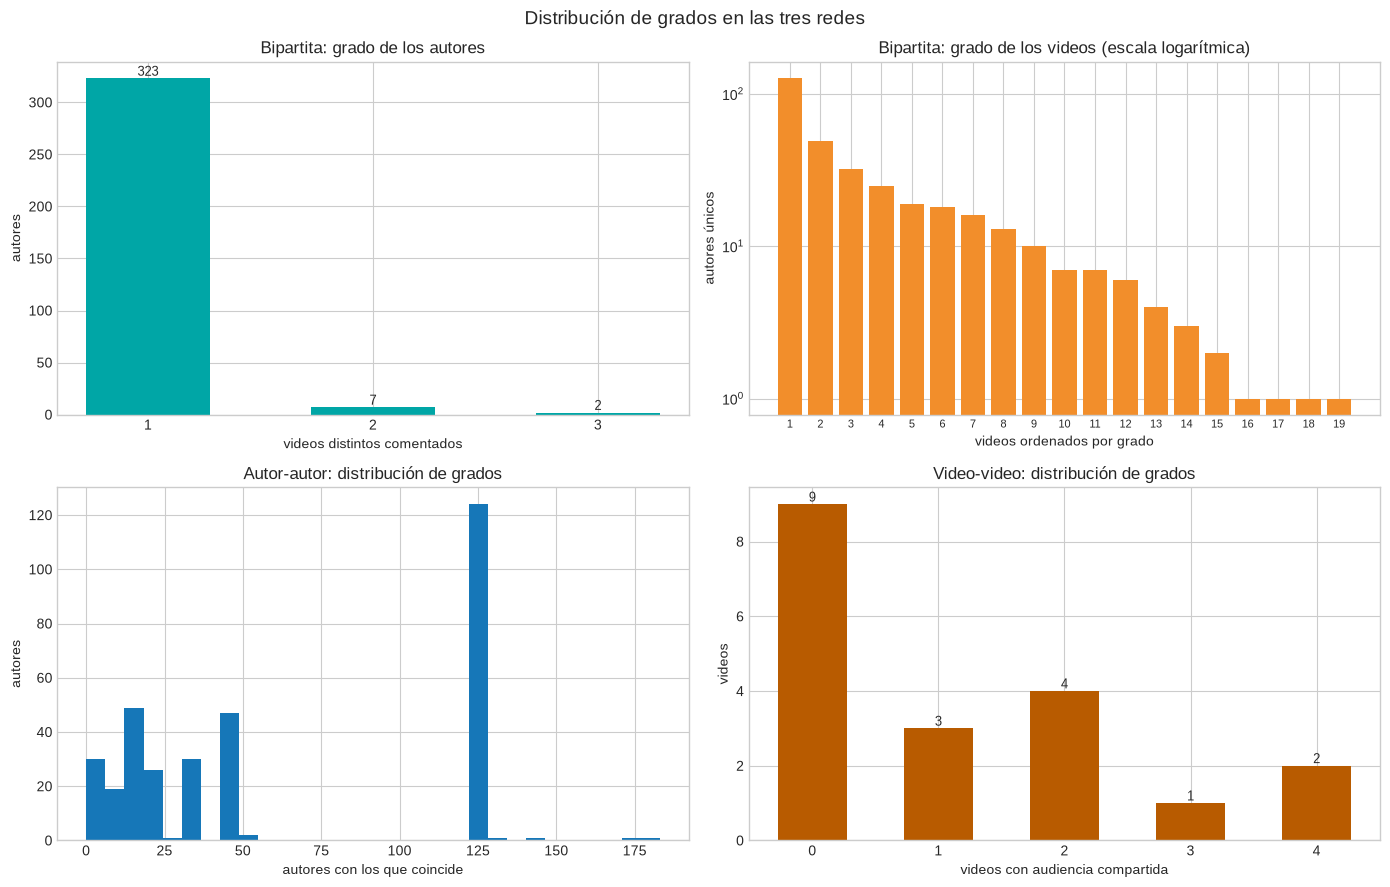

In [5]:
fig, ejes = plt.subplots(2, 2, figsize=(14, 9))

conteo_autores = grados_autor.value_counts().sort_index()
ejes[0, 0].bar(conteo_autores.index, conteo_autores.values, color="#00A6A6", width=0.55)
for x, y in zip(conteo_autores.index, conteo_autores.values):
    ejes[0, 0].text(x, y, f"{y}", ha="center", va="bottom", fontsize=9)
ejes[0, 0].set_title("Bipartita: grado de los autores")
ejes[0, 0].set_xlabel("videos distintos comentados")
ejes[0, 0].set_ylabel("autores")
ejes[0, 0].set_xticks(conteo_autores.index)

orden_video = grados_video.sort_values(ascending=False)
posiciones = np.arange(1, len(orden_video) + 1)
ejes[0, 1].bar(posiciones, orden_video.values, color="#F28E2B")
ejes[0, 1].set_yscale("log")
ejes[0, 1].set_title("Bipartita: grado de los videos (escala logarítmica)")
ejes[0, 1].set_xlabel("videos ordenados por grado")
ejes[0, 1].set_ylabel("autores únicos")
ejes[0, 1].set_xticks(posiciones)
ejes[0, 1].tick_params(axis="x", labelsize=8)

grados_proj_aa = np.array([d for _, d in G_aa.degree()])
ejes[1, 0].hist(grados_proj_aa, bins=30, color="#1677B8")
ejes[1, 0].set_title("Autor-autor: distribución de grados")
ejes[1, 0].set_xlabel("autores con los que coincide")
ejes[1, 0].set_ylabel("autores")

conteo_vv = pd.Series([d for _, d in G_vv.degree()]).value_counts().sort_index()
ejes[1, 1].bar(conteo_vv.index, conteo_vv.values, color="#B85B00", width=0.55)
for x, y in zip(conteo_vv.index, conteo_vv.values):
    ejes[1, 1].text(x, y, f"{y}", ha="center", va="bottom", fontsize=9)
ejes[1, 1].set_title("Video-video: distribución de grados")
ejes[1, 1].set_xlabel("videos con audiencia compartida")
ejes[1, 1].set_ylabel("videos")
ejes[1, 1].set_xticks(conteo_vv.index)

fig.suptitle("Distribución de grados en las tres redes", fontsize=14)
plt.tight_layout()
plt.show()

La distribución es fuertemente asimétrica en la red bipartita: 323 de 332 autores comentaron un
solo video y los grados de los videos van de 1 a 128. En la proyección autor-autor los grados se
agrupan en valores discretos que corresponden al tamaño de la camarilla de cada video, no a una
distribución continua de popularidad.

In [6]:
def tabla_componentes(G, nombre):
    filas = []
    for i, comp in enumerate(sorted(nx.connected_components(G), key=len, reverse=True), start=1):
        sub = G.subgraph(comp)
        videos_comp = [n for n in comp if n in VIDEOS] if nombre == "bipartita" else []
        filas.append({
            "red": nombre,
            "componente": i,
            "nodos": sub.number_of_nodes(),
            "aristas": sub.number_of_edges(),
            "autores": sub.number_of_nodes() - len(videos_comp) if nombre == "bipartita" else np.nan,
            "videos": len(videos_comp) if nombre == "bipartita" else np.nan,
            "contenido": ", ".join(sorted(etiqueta_nodo[v][:32] for v in videos_comp)) if videos_comp else "",
        })
    return pd.DataFrame(filas)

componentes_bip = tabla_componentes(B, "bipartita")
print(f"Componentes de la red bipartita: {len(componentes_bip)}")
print(f"Aristas puente dentro de la componente mayor: "
      f"{len(list(nx.bridges(B.subgraph(max(nx.connected_components(B), key=len)))))}")
componentes_bip

Componentes de la red bipartita: 10
Aristas puente dentro de la componente mayor: 279


,red,componente,nodos,aristas,autores,videos,contenido
0,bipartita,1,286,287,276,10,"Arroz con pollo a la MONOPOLIO, Bloqueos en Guatemala es..."
1,bipartita,2,26,25,25,1,Plan 2032 Ciudad de Guatemala
2,bipartita,3,19,18,18,1,EE.UU. envía a mexicanos deporta
3,bipartita,4,5,4,4,1,I’x K’at: el primer equipo guate
4,bipartita,5,4,3,3,1,10 Preguntas a un año del Paro N
5,bipartita,6,3,2,2,1,"Noticiero en Directo 1 pm, 28 de"
6,bipartita,7,2,1,1,1,¿Quiénes pagan más en Centroamér
7,bipartita,8,2,1,1,1,Cruzando la ciudad a puro Transm
8,bipartita,9,2,1,1,1,Edén por Salud: empleo inclusivo
9,bipartita,10,2,1,1,1,SHAI WA: la vecina queer de Casa


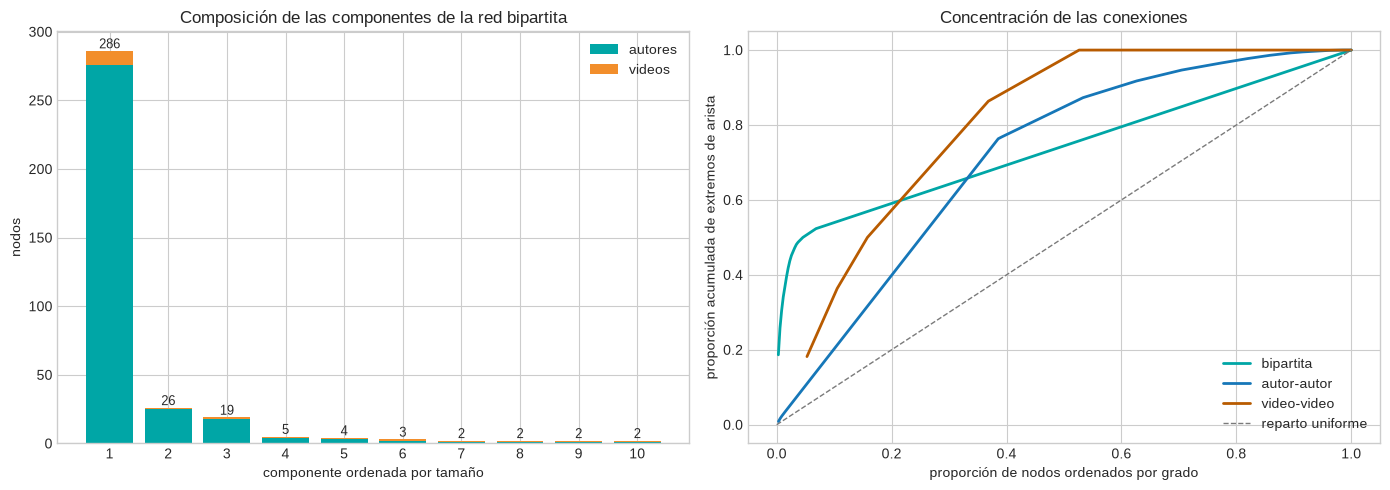

In [7]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(componentes_bip))
ejes[0].bar(x, componentes_bip["autores"], color="#00A6A6", label="autores")
ejes[0].bar(x, componentes_bip["videos"], bottom=componentes_bip["autores"], color="#F28E2B", label="videos")
for i, fila in componentes_bip.iterrows():
    ejes[0].text(i, fila["nodos"], f"{int(fila['nodos'])}", ha="center", va="bottom", fontsize=9)
ejes[0].set_title("Composición de las componentes de la red bipartita")
ejes[0].set_xlabel("componente ordenada por tamaño")
ejes[0].set_ylabel("nodos")
ejes[0].set_xticks(x, componentes_bip["componente"])
ejes[0].legend()

for nombre, G, color in [("bipartita", B, "#00A6A6"), ("autor-autor", G_aa, "#1677B8"),
                         ("video-video", G_vv, "#B85B00")]:
    grados = np.sort(np.array([d for _, d in G.degree()]))[::-1]
    ejes[1].plot(np.arange(1, len(grados) + 1) / len(grados),
                 np.cumsum(grados) / grados.sum(), color=color, linewidth=2, label=nombre)
ejes[1].plot([0, 1], [0, 1], color="#7A7A7A", linestyle="--", linewidth=1, label="reparto uniforme")
ejes[1].set_title("Concentración de las conexiones")
ejes[1].set_xlabel("proporción de nodos ordenados por grado")
ejes[1].set_ylabel("proporción acumulada de extremos de arista")
ejes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 6.2 Cohesión y transitividad

La transitividad global cuenta triángulos. En una red bipartita no existen triángulos por
construcción, de modo que su valor es 0 y no aporta información. Para esa red se usan dos
coeficientes propios del caso bipartito: el de Latapy, que compara los vecindarios de nodos del
mismo tipo, y el de Robins y Alexander, basado en ciclos de longitud cuatro, es decir, en pares de
autores que coinciden en dos videos distintos.

Como medidas de cohesión estructural se calculan la conectividad de nodos y de aristas de la
componente mayor, sus puntos de articulación y sus puentes.

In [8]:
def cohesion(G, nombre, bipartita=False):
    mayor = G.subgraph(max(nx.connected_components(G), key=len))
    fila = {
        "red": nombre,
        "transitividad global": nx.transitivity(G),
        "clustering medio": nx.average_clustering(G),
        "conectividad de nodos (comp. mayor)": nx.node_connectivity(mayor),
        "conectividad de aristas (comp. mayor)": nx.edge_connectivity(mayor),
        "puntos de articulación": len(list(nx.articulation_points(mayor))),
        "puentes": len(list(nx.bridges(mayor))),
        "aristas de la comp. mayor": mayor.number_of_edges(),
    }
    if bipartita:
        latapy = bip.clustering(G)
        fila["clustering bipartito (autores)"] = np.mean([latapy[n] for n in AUTORES])
        fila["clustering bipartito (videos)"] = np.mean([latapy[n] for n in VIDEOS])
        fila["Robins-Alexander"] = bip.robins_alexander_clustering(G)
    return fila

cohesiones = pd.DataFrame([
    cohesion(B, "bipartita", bipartita=True),
    cohesion(G_aa, "autor-autor"),
    cohesion(G_vv, "video-video"),
]).set_index("red").T
cohesiones

red,bipartita,autor-autor,video-video
transitividad global,0.000,0.984,0.316
clustering medio,0.000,0.972,0.149
conectividad de nodos (comp. mayor),1.000,1.000,1.000
conectividad de aristas (comp. mayor),1.000,5.000,1.000
puntos de articulación,17.000,7.000,5.000
puentes,279.000,0.000,5.000
aristas de la comp. mayor,287.000,"10,269.000",11.000
clustering bipartito (autores),0.942,NaN,NaN
clustering bipartito (videos),0.014,NaN,NaN
Robins-Alexander,0.008,NaN,NaN


In [9]:
ciclos_4 = int((aristas_aa["weight"] * (aristas_aa["weight"] - 1) / 2).sum())
puentes_mayor = len(list(nx.bridges(B.subgraph(max(nx.connected_components(B), key=len)))))
aristas_mayor = B.subgraph(max(nx.connected_components(B), key=len)).number_of_edges()

print(f"Ciclos de longitud 4 en la red bipartita: {ciclos_4}")
print(f"Puentes en la componente mayor: {puentes_mayor} de {aristas_mayor} aristas "
      f"({100 * puentes_mayor / aristas_mayor:.1f}%)")

nucleos = pd.Series(nx.core_number(G_aa)).value_counts().sort_index()
print("\nDescomposición en k-núcleos de la proyección autor-autor")
print(nucleos.rename_axis("k").rename("autores").to_string())

Ciclos de longitud 4 en la red bipartita: 2
Puentes en la componente mayor: 279 de 287 aristas (97.2%)

Descomposición en k-núcleos de la proyección autor-autor
k
0        4
1        2
2        3
3        4
5        5
6       12
9        7
12      12
15      16
17      18
18      17
24      25
31      32
48      47
127    128


La red bipartita es casi un árbol: el 97% de las aristas de su componente mayor son puentes y solo
existen dos ciclos de longitud cuatro, es decir, solo dos pares de autores coinciden en más de un
video. El coeficiente de Robins y Alexander de 0.008 confirma que casi no hay participación
redundante entre contenidos.

El contraste entre los dos coeficientes bipartitos es informativo. El valor alto del lado de los
autores (0.94) se debe a que 323 de ellos tienen grado 1: sus vecindarios coinciden por completo
con los de quienes comentaron el mismo video. El valor bajo del lado de los videos (0.014) muestra
que las audiencias de los videos casi no se solapan.

La transitividad de 0.98 en la proyección autor-autor no indica cohesión social. Es la consecuencia
directa de proyectar: cada video produce una camarilla completa, donde toda tripleta está cerrada.
Los k-núcleos reproducen exactamente los tamaños de esas camarillas.

La conectividad de nodos de la componente mayor es 1 en las tres redes: basta eliminar un nodo para
partirla. La conectividad de aristas también es 1 en la bipartita y en la video-video, mientras que
en la proyección autor-autor sube a 5, otra vez por efecto de las camarillas y no por redundancia
real de la participación.

## 6.3 Nodos periféricos, aislados y ausencia de datos

Se distinguen tres situaciones que no deben confundirse: aislamiento observado dentro de la red,
periferia con conexiones mínimas y ausencia de datos por el diseño de la recolección.

In [10]:
videos_con_comentarios = set(nodos_bip.loc[nodos_bip["node_type"] == "video", "raw_id"])
sin_comentarios = catalogo[~catalogo["video_id"].isin(videos_con_comentarios)]

aislados_aa = [n for n, d in G_aa.degree() if d == 0]
aislados_vv = [n for n, d in G_vv.degree() if d == 0]

diagnostico = pd.DataFrame([
    {"situación": "Videos del catálogo sin comentarios recolectados",
     "casos": len(sin_comentarios), "naturaleza": "ausencia de datos"},
    {"situación": "Videos con comentarios pero sin audiencia compartida (aislados en video-video)",
     "casos": len(aislados_vv), "naturaleza": "aislamiento observado"},
    {"situación": "Autores sin ningún coparticipante (aislados en autor-autor)",
     "casos": len(aislados_aa), "naturaleza": "aislamiento observado"},
    {"situación": "Autores con un solo video comentado (periferia de la bipartita)",
     "casos": int((grados_autor == 1).sum()), "naturaleza": "periferia observada"},
    {"situación": "Autores con un solo comentario en todo el conjunto",
     "casos": int((nodos_bip.loc[nodos_bip["node_type"] == "author", "comment_count"] == 1).sum()),
     "naturaleza": "periferia observada"},
])
print(f"Catálogo: {len(catalogo)} videos, {len(videos_con_comentarios)} con comentarios "
      f"({100 * len(videos_con_comentarios) / len(catalogo):.1f}%)")
diagnostico

Catálogo: 293 videos, 19 con comentarios (6.5%)


,situación,casos,naturaleza
0,Videos del catálogo sin comentarios recolectados,274,ausencia de datos
1,Videos con comentarios pero sin audiencia compartida (ai...,9,aislamiento observado
2,Autores sin ningún coparticipante (aislados en autor-autor),4,aislamiento observado
3,Autores con un solo video comentado (periferia de la bip...,323,periferia observada
4,Autores con un solo comentario en todo el conjunto,286,periferia observada


In [11]:
print("Videos aislados en la proyección video-video")
print(nodos_vv[nodos_vv["video_id"].isin(aislados_vv)][
    ["video_id", "label", "channel_name", "unique_authors", "comment_count", "view_count"]
].to_string(index=False))

print("\nAutores aislados en la proyección autor-autor")
print(nodos_aa[nodos_aa["author_channel_id"].isin(aislados_aa)][
    ["author_channel_id", "label", "comment_count", "videos_commented"]
].to_string(index=False))

print("\nComponentes menores de la red bipartita (todo lo que no es la componente mayor)")
print(componentes_bip[componentes_bip["componente"] > 1][
    ["componente", "nodos", "autores", "videos", "contenido"]].to_string(index=False))

Videos aislados en la proyección video-video
   video_id                                                                                             label                  channel_name  unique_authors  comment_count  view_count
3Nfp9h5avBI                                                   Noticiero en Directo 1 pm, 28 de Agosto de 2026 Noticiero Guatevisión 13 Hrs.               2              2         573
JkpVO1hx2f8                                                           10 Preguntas a un año del Paro Nacional                        Quorum               3              3         673
OkXlHx0hx-8 EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo            Noticias Telemundo              18             25       14200
TT4qJ5FXHYE        I’x K’at: el primer equipo guatemalteco de pelota maya, conformado únicamente por mujeres.                        Quorum               4              4        1075
UhL9y3KUl8E                             

Los 9 videos aislados en la proyección video-video sí recibieron comentarios: su aislamiento es
observado y significa que ninguno de sus comentaristas apareció en otro video de la muestra. Los
274 videos del catálogo sin comentarios no son nodos aislados sino contenidos fuera de la
recolección: no aparecen en ninguna red y no puede afirmarse nada sobre su participación.

Los 4 autores aislados en la proyección autor-autor comentaron en videos donde fueron el único
comentarista recolectado. Nuevamente, esto describe la muestra y no la actividad real del video.

## 6.4 Interpretación de los hallazgos estructurales

Estructura de estrellas, no de conversación. La red bipartita tiene 351 nodos y 343 aristas, una
relación cercana a la de un árbol, y su componente mayor tiene 97% de puentes. Cada video funciona
como el centro de una estrella de comentaristas que no vuelven a aparecer. La distancia media de
4.7 y el diámetro de 12 dentro de la componente mayor reflejan esa cadena de estrellas enlazadas
por unos pocos autores.

Fragmentación con un núcleo dominante. Hay 10 componentes en las tres redes. La mayor reúne el 81%
de los nodos de la bipartita e integra 10 videos de 5 canales; las 9 restantes son videos sueltos
con su público propio. Cuatro de esas componentes tienen apenas 2 nodos.

Concentración extrema. El 5% de los nodos de la bipartita concentra el 50.6% de los extremos de
arista. Un solo video reúne 128 de los 332 autores. La participación observada no se reparte, se
acumula en pocos contenidos.

Densidad y transitividad engañosas en la proyección. La proyección autor-autor parece muy cohesiva
(densidad 0.195, transitividad 0.98), pero esos valores son consecuencia mecánica de convertir cada
video en una camarilla. La medida que sí es informativa, el coeficiente de Robins y Alexander sobre
la bipartita, vale 0.008: la coparticipación repetida es prácticamente inexistente.

Fragilidad estructural. La conectividad de nodos es 1 en las tres redes. Eliminar un solo nodo, en
general un video muy comentado o uno de los pocos autores que participan en dos videos, parte la
componente mayor. El punto 8 identifica esos nodos concretos.